# Test of bundle adjustment.

### 1. Second order optimizer - LM, from pypose 
- work too slow
- 

### 2. First order optimized - Adam

In [1415]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1416]:
import os, sys
root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

import torch 
import torch.nn.functional as F
import numpy as np
import math
import time
from box import Box
import yaml
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from src.models.bundle_adjustment import BundleAdjustment
from src.models.utils import project_points

Generate synthetic data

In [1417]:


def generate_data(n_poses, n_pts, device, freeze_poses, sonar_param):
  
  pose_val_max = 20.0
  pose_noise_max_trans = 0.5
  pose_noise_max_rot = 0.12

  r_min = sonar_param.range.min
  r_max = sonar_param.range.max

  theta_min = -sonar_param.fov.horizontal / 2 
  theta_max = sonar_param.fov.horizontal / 2

  phi_min = -sonar_param.position.pitch 
  phi_max = phi_min - sonar_param.fov.vertical
  
  scale_factor = torch.tensor([sonar_param.resolution.bins / (sonar_param.range.max - sonar_param.range.min),
                               sonar_param.resolution.beams / sonar_param.fov.horizontal], device=device).view(1, 2)
  # gt poses
  poses_gt_list = []
  for i in range(n_poses):

    if i == 0:
      new_pose = torch.rand((1, 1, 7)) * pose_val_max
      new_pose[:, :, 3:] = F.normalize(new_pose[:, :, 3:], p=2.0, dim=-1)
    else:
      # prev_pose = poses_gt_list[-1]
      new_pose = poses_gt_list[-1] + torch.rand((1, 1, 7)) * pose_val_max / n_pts * 2
      new_pose[:, :, 3:] = F.normalize(new_pose[:, :, 3:], p=2.0, dim=-1)

    poses_gt_list.append(new_pose)

  poses_gt = torch.cat(poses_gt_list, dim=1)
  poses_gt[:, :, 3:] = F.normalize(poses_gt[:, :, 3:], p=2.0, dim=-1)

  poses_noise_t = poses_gt[:, freeze_poses:, :3] + (torch.rand((1, n_poses-freeze_poses, 3), device=device) - 0.5) * pose_noise_max_trans
  poses_noise_r = poses_gt[:, freeze_poses:, 3:] + (torch.rand((1, n_poses-freeze_poses, 4), device=device) - 0.5) * pose_noise_max_rot

  poses_noise = torch.cat([poses_noise_t, poses_noise_r], dim=-1)
  poses_noise = torch.cat([poses_gt[:, :freeze_poses, :], poses_noise], dim=1)
  poses_noise[:, :, 3:] = F.normalize(poses_noise[:, :, 3:], p=2.0, dim=-1)

  # points coords
  r = torch.rand(1, n_poses, n_pts, 1) * (r_max - r_min) + r_min
  theta = torch.rand(1, n_poses, n_pts, 1) * (theta_max - theta_min) + theta_min
  phi = torch.rand(1, n_poses, n_pts, 1) * (phi_max - phi_min) + phi_min

  coords_r_theta = torch.cat([r, theta], dim=-1)
  coords_stack = torch.cat([r, theta, phi], dim=-1)
  
  # edges 
  new_i, new_j = [], [] 
  for sf in range(n_poses): # for each source frame
    for tf in range(n_poses): # for each target frame
        if sf != tf: 
          # edges: new patches -> old frames
          new_i.append(torch.arange(sf * n_pts, (sf + 1) * n_pts, device=device)) 
          new_j.append(torch.full((n_pts,), tf, device=device))
          
          # edges: old patches -> new frame
          new_i.append(torch.arange((tf) * n_pts, (tf + 1) * n_pts, device=device))
          new_j.append(torch.full((n_pts,), sf, device=device))

  i = torch.cat(new_i, dim=0)
  j = torch.cat(new_j, dim=0)
  edges_num = i.shape[0]

  source_poses_idx = i // n_pts
  patch_idx = i
  target_poses_idx = j 
  
  source_coords = coords_stack.view(n_poses*n_pts, 3)[patch_idx]
  
  source_poses_gt = poses_gt.view(n_poses, 7)[source_poses_idx]
  target_poses_gt = poses_gt.view(n_poses, 7)[target_poses_idx]
  
  projection_gt = project_points(source_coords, source_poses_gt, target_poses_gt)   

  source_poses_noise = poses_noise.view(n_poses, 7)[source_poses_idx]
  target_poses_noise = poses_noise.view(n_poses, 7)[target_poses_idx]
  
  projection_noise = project_points(source_coords, source_poses_noise, target_poses_noise)  
            
  delta = (projection_gt - projection_noise)[:, :2] * scale_factor

  weights = torch.ones((edges_num, ))

  return (poses_gt, poses_noise, coords_r_theta, phi, source_poses_idx, target_poses_idx, patch_idx, delta, weights)
  




In [1418]:


sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

supervised = True
freeze_poses = 4

synthetic_data = generate_data(n_poses = 5, 
                               n_pts = 64, 
                               device = device, 
                               freeze_poses = freeze_poses, 
                               sonar_param = sonar_config)

poses_gt, poses_noise, coords_r_theta, coords_phi, source_poses_idx, target_poses_idx, patch_idx, delta, weights = synthetic_data
  

In [1419]:

def plot_trajectory_with_axes(poses, ax, axis_length=0.1, label='',color = 'black', skip=5):
    
    poses = poses.squeeze(0)
    
    # 1. Wyciągamy pozycje
    x = poses[:, 0]
    y = poses[:, 1]
    z = poses[:, 2]

    # Rysujemy główną linię trajektorii
    ax.plot(x, y, z, color=color, label=label, linestyle='-', linewidth=2)

    # 2. Wyciągamy kwaterniony i konwertujemy na macierze rotacji
    # Uwaga: SciPy domyślnie oczekuje [x, y, z, w]. Jeśli masz [w, x, y, z], użyj odpowiedniego mapowania.
    quats = poses[:, 3:]
    rotations = R.from_quat(quats)

    # Definiujemy bazowe wektory osi (X, Y, Z)
    identity_axes = np.eye(3) * axis_length

    # 3. Dodajemy osie w co n-tym punkcie (skip), aby wykres był czytelny
    for i in range(0, len(poses), skip):
        pos = poses[i, :3]
        # Obracamy bazowe osie zgodnie z orientacją w danym punkcie
        # rotations[i].apply(...) zwraca wektory osi w układzie globalnym
        dir_x = rotations[i].apply([axis_length, 0, 0])
        dir_y = rotations[i].apply([0, axis_length, 0])
        dir_z = rotations[i].apply([0, 0, axis_length])

        # Rysujemy strzałki: czerwona (X), zielona (Y), niebieska (Z)
        ax.quiver(pos[0], pos[1], pos[2], dir_x[0], dir_x[1], dir_x[2], color='r', alpha=0.8)
        ax.quiver(pos[0], pos[1], pos[2], dir_y[0], dir_y[1], dir_y[2], color='g', alpha=0.8)
        ax.quiver(pos[0], pos[1], pos[2], dir_z[0], dir_z[1], dir_z[2], color='b', alpha=0.8)




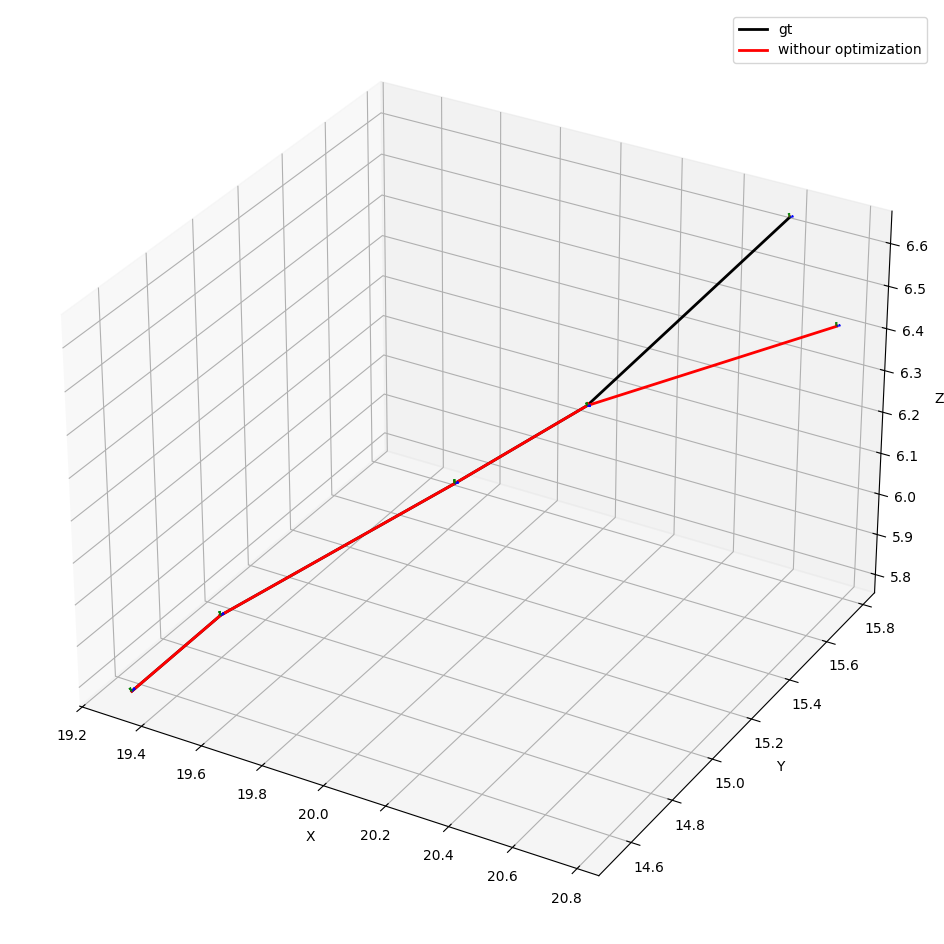

In [1420]:
# plot synthetic data

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

plot_trajectory_with_axes(poses_gt, ax, axis_length=0.01, label='gt', color = 'black', skip=1)
plot_trajectory_with_axes(poses_noise, ax, axis_length=0.01, label='withour optimization', color = 'red', skip=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

Optimization with 100 teration to prove that BA works 

Loss 0 iter: 0.0114 | r err: 0.1330 | theta err: 0.2187
Loss 1 iter: 0.0241 | r err: 0.1406 | theta err: 0.4604
Loss 2 iter: 0.0209 | r err: 0.1989 | theta err: 0.3444
Loss 3 iter: 0.0221 | r err: 0.2017 | theta err: 0.3152
Loss 4 iter: 0.0209 | r err: 0.2077 | theta err: 0.3095
Loss 5 iter: 0.0238 | r err: 0.2168 | theta err: 0.3783
Loss 6 iter: 0.0266 | r err: 0.2169 | theta err: 0.4382
Loss 7 iter: 0.0288 | r err: 0.2144 | theta err: 0.4834
Loss 8 iter: 0.0296 | r err: 0.2106 | theta err: 0.5058
Loss 9 iter: 0.0294 | r err: 0.2057 | theta err: 0.5108
Loss 10 iter: 0.0289 | r err: 0.2001 | theta err: 0.5069
Loss 11 iter: 0.0280 | r err: 0.1904 | theta err: 0.4981


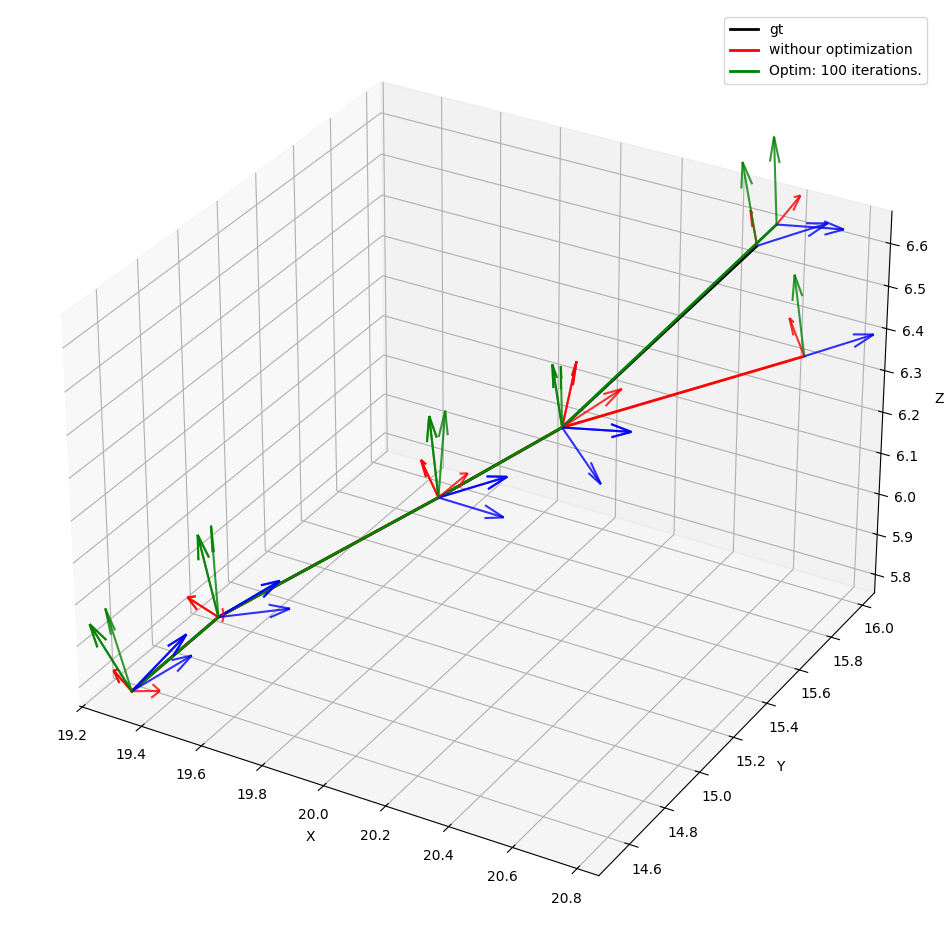

Initialization time: 0.004000425338745117
Mean optim iter time: 0.0012002873420715332
Total optim time: 0.12002873420715332


In [1421]:
iter_num_max = 100

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

plot_trajectory_with_axes(poses_gt, ax, axis_length=0.2, label='gt', color = 'black', skip=1)
plot_trajectory_with_axes(poses_noise, ax, axis_length=0.2, label='withour optimization', color = 'red', skip=1)


t_init_start = time.time()

BA = BundleAdjustment(supervised, poses_noise.detach(),
                    coords_r_theta.detach(), coords_phi.detach(), 
                    source_poses_idx.detach(), target_poses_idx.detach(), patch_idx.detach(),
                    delta.detach(), weights.detach(), 
                    sonar_config, freeze_poses)
BA.to(device)

# torch.cuda.synchronize()
t_init_end = time.time()

t_optim_start = time.time()
with torch.no_grad():
    poses_optimized, elevation_optimized = BA.run(max_iter=iter_num_max, patience = 10, min_delta = 1e-4,
                                                    lr_elev=0.05, lr_rot=0.05, lr_trans = 0.2,
                                                    disp_stats=True)

# torch.cuda.synchronize()
t_optim_end = time.time()
plot_trajectory_with_axes(poses_optimized, ax, axis_length=0.2, label=f'Optim: {iter_num_max} iterations.', color = 'green', skip=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

print(f'Initialization time: {t_init_end - t_init_start}')
print(f'Mean optim iter time: {(t_optim_end - t_optim_start)/iter_num_max}')
print(f'Total optim time: {(t_optim_end - t_optim_start)}')

Pipeline similar to real time estimation, frame by frame to choose parameters.

In [1422]:


# num_frames = poses_noise.shape[1]

# for i in range(num_frames):
#     poses_act = poses_noise[:, :i, :]


#     source_poses_idx_act = source_poses_idx[:]
#     target_poses_idx_act = target_poses_idx[]
#     patch_idx_act = patch_idx[]
#     delta_act = delta
#     weights_act =weights
    
# iter_num_max = 100

# fig = plt.figure(figsize=(12, 12))
# ax = fig.add_subplot(111, projection='3d')

# plot_trajectory_with_axes(poses_gt, ax, axis_length=0.2, label='gt', color = 'black', skip=1)
# plot_trajectory_with_axes(poses_noise, ax, axis_length=0.2, label='withour optimization', color = 'red', skip=1)


# t_init_start = time.time()

# BA = BundleAdjustment(supervised, poses_noise.detach(),
#                     coords_r_theta.detach(), coords_phi.detach(), 
#                     source_poses_idx.detach(), target_poses_idx.detach(), patch_idx.detach(),
#                     delta.detach(), weights.detach(), 
#                     sonar_config, freeze_poses)
# BA.to(device)

# # torch.cuda.synchronize()
# t_init_end = time.time()

# t_optim_start = time.time()
# with torch.no_grad():
#     poses_optimized, elevation_optimized = BA.run(max_iter=iter_num_max, patience = 10, min_delta = 1e-4,
#                                                     lr_elev=0.01, lr_rot=0.02, lr_trans = 0.5,
#                                                     disp_stats=True)

# # torch.cuda.synchronize()
# t_optim_end = time.time()
# plot_trajectory_with_axes(poses_optimized, ax, axis_length=0.2, label=f'Optim: {iter_num_max} iterations.', color = 'green', skip=1)

# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.legend()
# plt.show()

# print(f'Initialization time: {t_init_end - t_init_start}')
# print(f'Mean optim iter time: {(t_optim_end - t_optim_start)/iter_num_max}')
# print(f'Total optim time: {(t_optim_end - t_optim_start)}')

In [1423]:


# iter_num_max = 5
# lr = 0.2



# fig = plt.figure(figsize=(12, 12))
# ax = fig.add_subplot(111, projection='3d')

# plot_trajectory_with_axes(poses_gt, ax, axis_length=0.4, label='gt', color = 'black', skip=1)
# plot_trajectory_with_axes(poses_noise, ax, axis_length=0.4, label='withour optimization', color = 'red', skip=1)


# color_list = ['green', 'blue', 'skyblue', 'salmon', 'yellow', 'gold', 'crimson', 'darkviolet']

# for iter_num in range(iter_num_max):

#     BA = BundleAdjustment(supervised, poses_noise.detach(),
#                         coords_r_theta.detach(), coords_phi.detach(), 
#                         source_poses_idx.detach(), target_poses_idx.detach(), patch_idx.detach(),
#                         delta.detach(), weights.detach(), 
#                         sonar_config, freeze_poses)
#     BA.to(device)

#     with torch.no_grad():
#         poses_optimized, elevation_optimized = BA.run(max_iter=iter_num,
#                                                         lr = lr,
#                                                         disp_stats=True)
        
#     plot_trajectory_with_axes(poses_optimized, ax, axis_length=0.4, label=f'Optim: {iter_num} iterations.', color = color_list[iter_num], skip=1)


# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.legend()
# plt.show()